
# Lab 5: Scrodinger equation with FDM

 **Exercise** : Solve the radial Schrodinger for Hydrogen atom with FDM

 ### Hydrogen radial equation

The H atom has an electron of mass $m$ a $r$ distance to the pronton. The potential energy is given by

$U(r)= -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}$

The Schrodinger's equation for this system is

$$
-\dfrac{\hbar^2}{2m}\nabla^2 \psi(\vec{r}) + -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}\psi(\vec{r})= E\,\psi(\vec{r})$$

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters in atomic units
hbar = 1
m = 1

# Radial grid
rmax = 30
N = 800

r = np.linspace(1e-5, rmax, N)
dr = r[1] - r[0]

# Interior points: u(0) = u(rmax) = 0
ri = r[1:-1]

# Hydrogen potential for l = 0
U = -1/ri

# Hamiltonian matrix
M = len(ri)
H = np.zeros((M, M))

for i in range(M):
    H[i, i] = hbar**2/(m*dr**2) + U[i]

    if i > 0:
        H[i, i-1] = -hbar**2/(2*m*dr**2)

    if i < M-1:
        H[i, i+1] = -hbar**2/(2*m*dr**2)

# Eigenvalues and eigenvectors
E, u = np.linalg.eigh(H)

# Normalize the radial wave functions
for i in range(4):
    area = np.trapezoid(u[:, i]**2, x=ri)
    u[:, i] = u[:, i]/np.sqrt(area)

# First four energy levels
print("Energy levels:")
for i in range(4):
    print(f"E_{i+1} = {E[i]:.6f} Hartree")

Energy levels:
E_1 = -0.499805 Hartree
E_2 = -0.124987 Hartree
E_3 = -0.055421 Hartree
E_4 = -0.024637 Hartree


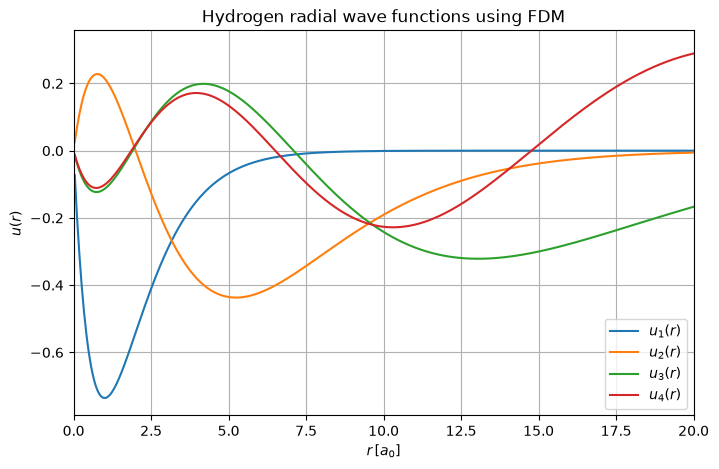

In [4]:
# Radial wave functions
plt.figure(figsize=(8,5))

for i in range(4):
    plt.plot(ri, u[:, i], label=fr'$u_{i+1}(r)$')

plt.xlabel(r'$r\,[a_0]$')
plt.ylabel(r'$u(r)$')
plt.title('Hydrogen radial wave functions using FDM')
plt.xlim(0, 20)
plt.legend()
plt.grid()
plt.show()

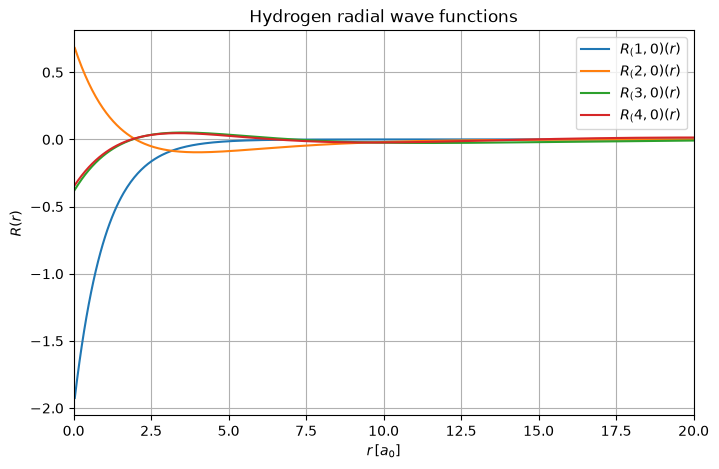

In [5]:
R = u[:, :4] / ri[:, None]

plt.figure(figsize=(8,5))

for i in range(4):
    plt.plot(ri, R[:, i], label=fr'$R_{i+1,0}(r)$')

plt.xlabel(r'$r\,[a_0]$')
plt.ylabel(r'$R(r)$')
plt.title('Hydrogen radial wave functions')
plt.xlim(0, 20)
plt.legend()
plt.grid()
plt.show()